<a href="https://colab.research.google.com/github/Karthy5/complaints_handler/blob/main/Categorization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install classy_classification

INFO: pip is looking at multiple versions of spacy-transformers to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of spacy-transformers to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 375.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.2/756.2 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
!python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 19.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
!python -m spacy download en_core_web_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 4.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [4]:
import spacy
import classy_classification

In [ ]:
data = {
    "Safety": ["The train is not safe."
                "The train is on fire.",
               "I smell a gas leak.",
               "There are some suspicious individuals that have boarded the train."],
    "Medic": ["My sister is having a heart attack.",
              "I am in need of urgent medical assistance."
              "An old man is dying."
              "Urgent medical assistance needed."],
    "Cleanliness": ["The seats are dirty.",
                    "The station is full of trash.",
                    "The pungent smell of the bathrooms are unbearable."
                    "Dirty", "Unclean"],
    "Infra Damage": ["The platform is cracked and uneven, causing a tripping hazard.",
                    "There are broken lights on the station platform making it unsafe to board the train at night.",
    "The staircase leading to the train is damaged and unstable.", "Building damage", "Train damage."],

    "Technical": [
    "The website server has been down for the past 12 hours.",
    "Your server has crashed.",
    "The website is not running."],

    "Timings": [
    "The train was delayed by more than 3 hours without any prior notice.",
    "The departure time of the train was changed at the last minute, causing confusion.",
    "The train arrived at the station 30 minutes early, and we missed our connecting train."],

    "Booking / Cancellation / Refund": [
    "I was charged twice for my train ticket, but the refund process is taking too long.",
    "I tried to cancel my ticket online, but the system keeps showing an error.",
    "I did not receive a confirmation email for my booking, and I am unsure if my reservation is confirmed."
    "I want to cancel my ticket.", "I want a refund."],

    "Accessibility": [
    "There are no ramps or elevators for wheelchair users at this station.",
    "The train does not have sufficient space or facilities for passengers with disabilities.",
    "There is no assistance available for elderly passengers or those with mobility issues at the station."],

    "Theft": [
    "My wallet was stolen from my bag while I was asleep on the train.",
    "There are reports of thefts happening frequently on this train route.",
    "I had some valuable items stolen from my luggage while it was stored in the overhead rack.",
    "I have been robbed."],

    "Service": [
    "The train staff are not responding to requests for help or assistance.",
    "The food served on the train is of poor quality and does not match the description.",
    "The cleaning staff are not attending to spills and messes in a timely manner."
    "The service is bad."]
}

In [ ]:
nlp = spacy.load("en_core_web_lg")

In [ ]:
22nlp = spacy.blank("en")
nlp.add_pipe(
    "classy_classification",
    config={
        "data": data,
        "model": "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
        "device": "cpu"
    }
)

sentence_model = spacy.blank("en")
sentence_model.add_pipe("sentencizer")
text = "There might be a gas leak. The A/C is not working. My sister is dying."
sentences = sentence_model(text)
final_data = []
for sentence in sentences.sents:
    doc = nlp(sentence.text)
    final_data.append({"sentence": doc.text, "cats":doc._.cats})
    print(doc)
    print(doc._.cats)

  warnings.warn(



There might be a gas leak.
{'Accessibility': 0.026675929260554735, 'Booking / Cancellation / Refund': 0.036607625657168755, 'Cleanliness': 0.17897113245344753, 'Infra Damage': 0.1529745877312939, 'Medic': 0.1317729247020369, 'Safety': 0.24223515990238065, 'Service': 0.06311066244059522, 'Technical': 0.04848552823002683, 'Theft': 0.07351881112748683, 'Timings': 0.04564763849500858}
The A/C is not working.
{'Accessibility': 0.09192719435241485, 'Booking / Cancellation / Refund': 0.07757340199154975, 'Cleanliness': 0.0929188333453036, 'Infra Damage': 0.052032731945579204, 'Medic': 0.15856714807218653, 'Safety': 0.05218322210758402, 'Service': 0.24511460471864702, 'Technical': 0.09803631606880618, 'Theft': 0.047518779614925954, 'Timings': 0.08412776778300275}
My sister is dying.
{'Accessibility': 0.028738763208808027, 'Booking / Cancellation / Refund': 0.024661857815988657, 'Cleanliness': 0.08616753195465272, 'Infra Damage': 0.026366530858666082, 'Medic': 0.646988998399128, 'Safety': 0.043

In [ ]:
result = nlp("The train was delayed by 2 hours without any prior notice.")._.cats
highest_category = max(result, key=result.get)
print(highest_category)

Timings


Defining expanded training data...
Expanded training data defined with 104 examples.

Training model with EXPANDED training data...
Model training complete.

Defining the independent test set...
Independent test set defined with 34 examples.

Getting predictions on the test data using the EXPANDED model...

Generating Confusion Matrix (with expanded training data)...


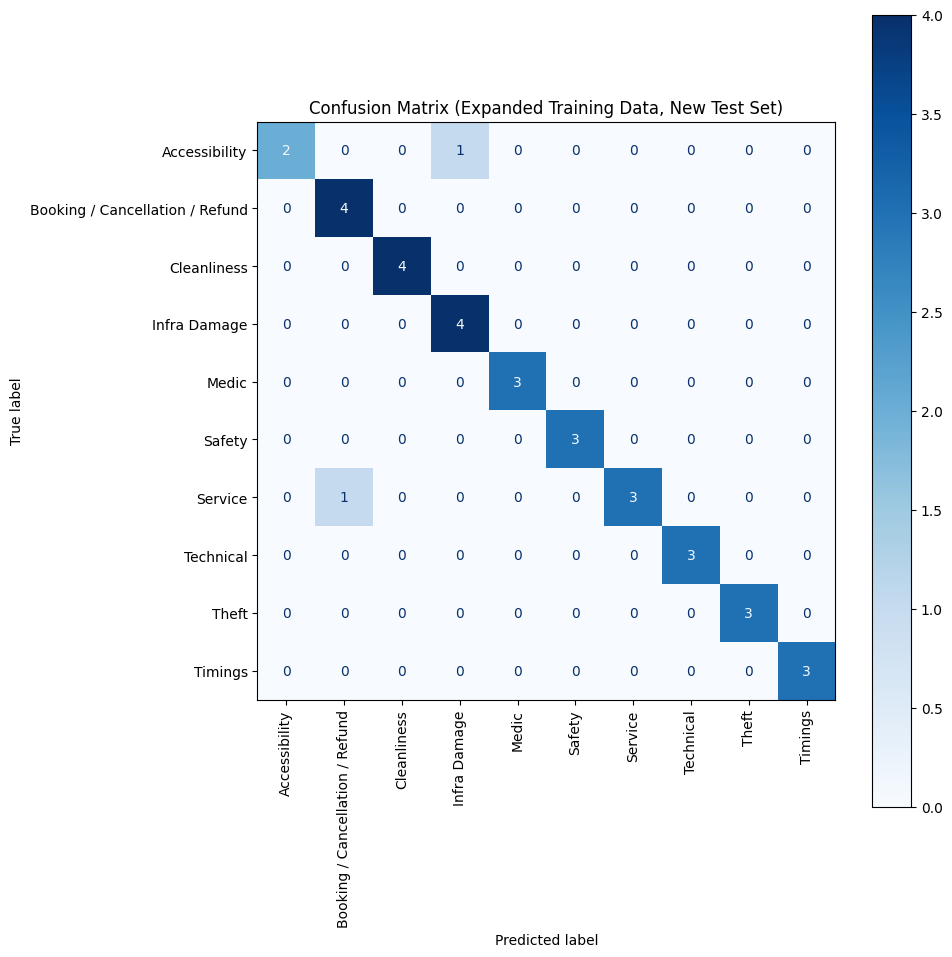


Confusion Matrix Interpretation:
- Rows represent the Actual (True) Labels (from the test set).
- Columns represent the Predicted Labels (by the model trained on expanded data).
- The diagonal elements show correct predictions for each class.
- Off-diagonal elements show misclassifications.

Compare this matrix to the one generated with the original, smaller training set.

--- Example Prediction using Expanded Model ---
Sentence: 'The train wifi is down and the heating isn't working in my carriage.'
Predicted Category: Infra Damage
All Scores: {'Accessibility': np.float64(0.0861742160270315), 'Booking / Cancellation / Refund': np.float64(0.052350659333198574), 'Cleanliness': np.float64(0.021246646230081958), 'Infra Damage': np.float64(0.21494251263519595), 'Medic': np.float64(0.018828733085709714), 'Safety': np.float64(0.18944172230397), 'Service': np.float64(0.11019226404959581), 'Technical': np.float64(0.15865193943019218), 'Theft': np.float64(0.01946710200816852), 'Timings': np.flo

In [8]:
# --- Installations (uncomment and run if you haven't already) ---
# !pip install classy_classification scikit-learn matplotlib numpy spacy
# !python -m spacy download en_core_web_lg # Using a transformer model, but good practice

import spacy
import classy_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Define Expanded Training Data ---
print("Defining expanded training data...")
expanded_data = {
    "Safety": [
        "The train is not safe.",
        "The train is on fire.",
        "I smell a gas leak.",
        "There are some suspicious individuals that have boarded the train.",
        "Emergency alarm activated due to smoke.",
        "Observed someone tampering with the train door mechanism.",
        "Fighting broke out in the next carriage.",
        "Feels unsafe due to poor lighting and lack of security.",
        "Derailment reported on this line earlier.",
        "Concerns about track safety ahead."
        ],
    "Medic": [
        "My sister is having a heart attack.",
        "I am in need of urgent medical assistance.",
        "An old man is dying.",
        "Urgent medical assistance needed.",
        "Passenger fainted, requires immediate medical help.",
        "Someone is choking, please help!",
        "Severe allergic reaction happening now.",
        "Requesting first aid for an injury.",
        "Paramedics needed at the next station.",
        "Experiencing chest pains, need a doctor."
        ],
    "Cleanliness": [
        "The seats are dirty.",
        "The station is full of trash.",
        "The pungent smell of the bathrooms are unbearable.",
        "Dirty",
        "Unclean",
        "Please clean up the spill in aisle 3.",
        "Toilets are blocked and overflowing.",
        "Graffiti on the walls.",
        "Food waste left on tables.",
        "Sticky floor near the entrance.",
        "Need sanitation crew attention."
        ],
    "Infra Damage": [
        "The platform is cracked and uneven, causing a tripping hazard.",
        "There are broken lights on the station platform making it unsafe to board the train at night.",
        "The staircase leading to the train is damaged and unstable.",
        "Building damage",
        "Train damage.",
        "Escalator is out of service again.",
        "Leaking roof in the waiting area.",
        "Broken window on the train carriage.",
        "Ticket barrier is malfunctioning / physically broken.",
        "Structural issues reported with the bridge.",
        "Damaged seating needs repair."
        ],
    "Technical": [
        "The website server has been down for the past 12 hours.",
        "Your server has crashed.",
        "The website is not running.",
        "Unable to log in to my account on the app.",
        "Payment gateway error during checkout.",
        "Wi-Fi connection is not working onboard.",
        "Digital display boards are showing incorrect information.",
        "App keeps crashing when I search for trains.",
        "Error message when trying to load e-ticket.",
        "The online timetable won't update."
        ],
    "Timings": [
        "The train was delayed by more than 3 hours without any prior notice.",
        "The departure time of the train was changed at the last minute, causing confusion.",
        "The train arrived at the station 30 minutes early, and we missed our connecting train.",
        "Constant delays on this route.",
        "Why is the train running so late?",
        "Schedule changes were not communicated properly.",
        "Missed connection due to late arrival.",
        "The estimated arrival time keeps changing.",
        "Train departed ahead of schedule.",
        "Frequency of trains reduced without warning."
        ],
    "Booking / Cancellation / Refund": [
        "I was charged twice for my train ticket, but the refund process is taking too long.",
        "I tried to cancel my ticket online, but the system keeps showing an error.",
        "I did not receive a confirmation email for my booking, and I am unsure if my reservation is confirmed.",
        "I want to cancel my ticket.",
        "I want a refund.",
        "Need to amend my travel dates.",
        "Issue with seat reservation.",
        "How do I apply for a refund for a cancelled train?",
        "Booking failed but money was deducted.",
        "Difficulty purchasing tickets via the app/website.",
        "Where is my refund status?"
        ],
    "Accessibility": [
        "There are no ramps or elevators for wheelchair users at this station.",
        "The train does not have sufficient space or facilities for passengers with disabilities.",
        "There is no assistance available for elderly passengers or those with mobility issues at the station.",
        "Need help boarding with a wheelchair.",
        "Lack of audio announcements for visually impaired passengers.",
        "No accessible restrooms available.",
        "Requesting assistance for a passenger with reduced mobility.",
        "Gap between train and platform is too large.",
        "Signage is unclear for finding accessible routes.",
        "Priority seating is occupied and not enforced."
        ],
    "Theft": [
        "My wallet was stolen from my bag while I was asleep on the train.",
        "There are reports of thefts happening frequently on this train route.",
        "I had some valuable items stolen from my luggage while it was stored in the overhead rack.",
        "I have been robbed.",
        "Someone pickpocketed me on the platform.",
        "My luggage was broken into.",
        "Reporting a stolen laptop.",
        "Suspicious activity, potential theft in progress.",
        "Warning about bag snatchers.",
        "Lost property likely due to theft."
        ],
    "Service": [
        "The train staff are not responding to requests for help or assistance.",
        "The food served on the train is of poor quality and does not match the description.",
        "The cleaning staff are not attending to spills and messes in a timely manner.", # Overlaps Cleanliness, but focuses on staff action
        "The service is bad.",
        "Rude conductor.",
        "Staff unable to provide information about delays.",
        "Air conditioning / heating is not working, staff unresponsive.", # Overlaps Infra, but focus on staff response/comfort service
        "Lack of onboard catering as advertised.",
        "Ticket inspector was unprofessional.",
        "No help available with luggage.",
        "Long queue at the ticket office, insufficient staff."
        ]
}
print(f"Expanded training data defined with {sum(len(v) for v in expanded_data.values())} examples.")

# --- 2. Train Model on EXPANDED Data ---
print("\nTraining model with EXPANDED training data...")
nlp_expanded = spacy.blank("en")
nlp_expanded.add_pipe(
    "classy_classification",
    config={
        "data": expanded_data, # Use the expanded data for training
        "model": "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
        "device": "cpu" # Change to "cuda" if GPU is available and configured
    }
)
print("Model training complete.")

# --- 3. Define the NEW Independent Test Set ---
# (Using the same test set as before to compare performance improvement)
print("\nDefining the independent test set...")
test_set = [
    # Safety
    ("Aggressive individual harassing passengers, feels unsafe.", "Safety"),
    ("Reported smoke coming from under the carriage.", "Safety"),
    ("Emergency brake was pulled.", "Safety"),

    # Medic
    ("A passenger has collapsed and needs medical help urgently.", "Medic"), # Kept original - fairly clear
    ("Is there a doctor on board? Someone is having trouble breathing.", "Medic"), # Kept original - fairly clear
    ("My child has a severe cut and is bleeding.", "Medic"), # More specific than 'dizzy'

    # Cleanliness
    ("Someone spilled coffee all over the floor and didn't clean it.", "Cleanliness"), # Kept original - fairly clear
    ("The restroom has no soap and the bin is overflowing.", "Cleanliness"), # Combined elements
    ("The seats are covered in stains and dirt.", "Cleanliness"), # More direct than 'grimy windows'
    ("Garbage piled up near the doors.", "Cleanliness"), # Clearer location

    # Infra Damage
    ("Major structural leak from ceiling onto platform.", "Infra Damage"), # More severe than 'dripping'
    ("The automatic door mechanism is broken and off its rails.", "Infra Damage"), # More specific than 'jammed'
    ("A large crack has appeared in the platform edge.", "Infra Damage"), # Clear structural issue
    ("The seat bracket is broken, seat is unstable.", "Infra Damage"), # Clear component failure

    # Technical
    ("Error code 503 on the website when trying to book.", "Technical"), # Specific error
    ("The mobile app keeps crashing whenever I search.", "Technical"), # Clear app failure
    ("Cannot connect to the onboard Wi-Fi network.", "Technical"), # Specific technical service

    # Timings
    ("Why does the announcement say delayed but the board shows on time?", "Timings"), # Kept original - clear discrepancy
    ("The train arrived 20 minutes late, causing me to miss my meeting.", "Timings"), # Clear consequence of delay
    ("My train just left 5 minutes before the scheduled departure time!", "Timings"), # Clear early departure

    # Booking / Cancellation / Refund
    ("I need to change my booking to a different date.", "Booking / Cancellation / Refund"), # Kept original - clear intent
    ("My ticket has the wrong name printed on it.", "Booking / Cancellation / Refund"), # Kept original - clear ticket issue
    ("Still waiting for the refund I was promised last week.", "Booking / Cancellation / Refund"), # Kept original - clear refund issue
    ("How do I reserve a specific seat number?", "Booking / Cancellation / Refund"), # Clear booking query

    # Accessibility
    ("The wheelchair lift at the station is broken.", "Accessibility"), # Specific accessibility equipment failure
    ("Is there priority seating available for elderly people?", "Accessibility"), # Kept original - clear query
    ("No audio announcements being made for arrivals/departures.", "Accessibility"), # Clear lack of auditory aid

    # Theft
    ("My phone was just snatched out of my hand!", "Theft"), # Kept original - clear theft
    ("Beware of pickpockets operating near the main entrance.", "Theft"), # Kept original - clear warning
    ("Someone broke into my locked suitcase in the luggage rack.", "Theft"), # Clear forced entry/theft

    # Service
    ("The conductor was very dismissive when I asked for directions.", "Service"), # Kept original - staff interaction
    ("Onboard cafe is closed despite advertised opening hours.", "Service"), # Service provision failure
    ("Staff ignored my request for help with heavy luggage.", "Service"), # Staff interaction failure
    ("Ticket inspector wrongly accused me of not having a valid ticket.", "Service") # Negative staff interaction
]

# Separate texts and true labels
test_texts = [item[0] for item in test_set]
true_labels = [item[1] for item in test_set]
print(f"Independent test set defined with {len(test_texts)} examples.")


# --- 4. Get Predictions on the Test Set using the EXPANDED Model ---
print("\nGetting predictions on the test data using the EXPANDED model...")
predicted_labels_expanded = []
for text in test_texts:
    doc = nlp_expanded(text) # Use the model trained on expanded data
    # Get the category with the highest score
    if not doc._.cats:
         print(f"Warning: No categories predicted for test text: '{text}'")
         predicted_label = "None" # Assign a default or handle as needed
    else:
         predicted_label = max(doc._.cats, key=doc._.cats.get)
    predicted_labels_expanded.append(predicted_label)
    # Optional: Print individual predictions vs true labels for debugging
    # print(f"Text: '{text}'\nTrue: {true_labels[len(predicted_labels_expanded)-1]}, Predicted: {predicted_label}\nScores: {doc._.cats}\n---")


# --- 5. Generate and Display the Confusion Matrix ---
print("\nGenerating Confusion Matrix (with expanded training data)...")

# Get all unique labels from the expanded training data + any defaults like "None"
all_labels_expanded = sorted(list(expanded_data.keys()))
if "None" in predicted_labels_expanded and "None" not in all_labels_expanded:
    all_labels_expanded.append("None")

try:
    # Calculate the confusion matrix
    cm_expanded = confusion_matrix(true_labels, predicted_labels_expanded, labels=all_labels_expanded)

    # Display the matrix
    disp_expanded = ConfusionMatrixDisplay(confusion_matrix=cm_expanded, display_labels=all_labels_expanded)

    fig_expanded, ax_expanded = plt.subplots(figsize=(10, 10)) # Adjust figure size if needed
    disp_expanded.plot(cmap=plt.cm.Blues, ax=ax_expanded, xticks_rotation='vertical')
    plt.title("Confusion Matrix (Expanded Training Data, New Test Set)")
    plt.tight_layout() # Adjust layout to prevent labels overlapping
    plt.show()

    print("\nConfusion Matrix Interpretation:")
    print("- Rows represent the Actual (True) Labels (from the test set).")
    print("- Columns represent the Predicted Labels (by the model trained on expanded data).")
    print("- The diagonal elements show correct predictions for each class.")
    print("- Off-diagonal elements show misclassifications.")
    print("\nCompare this matrix to the one generated with the original, smaller training set.")

except Exception as e:
    print(f"\nError generating confusion matrix: {e}")
    print("True Labels:", true_labels)
    print("Predicted Labels (Expanded):", predicted_labels_expanded)
    print("All Labels:", all_labels_expanded)

# --- Optional: Example Prediction ---
print("\n--- Example Prediction using Expanded Model ---")
example_text = "The train wifi is down and the heating isn't working in my carriage."
doc = nlp_expanded(example_text)
if doc._.cats:
    highest_category = max(doc._.cats, key=doc._.cats.get)
    print(f"Sentence: '{doc.text}'")
    print(f"Predicted Category: {highest_category}")
    print(f"All Scores: {doc._.cats}")
else:
    print(f"Sentence: '{doc.text}' - No prediction could be made.")

Defining FURTHER expanded training data (with added contrast examples)...
Enhanced training data defined with 144 examples.

Training model with ENHANCED (contrast added) training data...
Model re-training complete.

Defining the new BALANCED 'easier' test set (10 examples per category)...
New BALANCED 'easier' test set defined with 100 examples (10 per category).

Getting predictions on the 'easier' BALANCED 10-example test data using the FINAL model...

Generating Final Confusion Matrix (Enhanced Training, Easier Balanced 10-Example Test Set)...


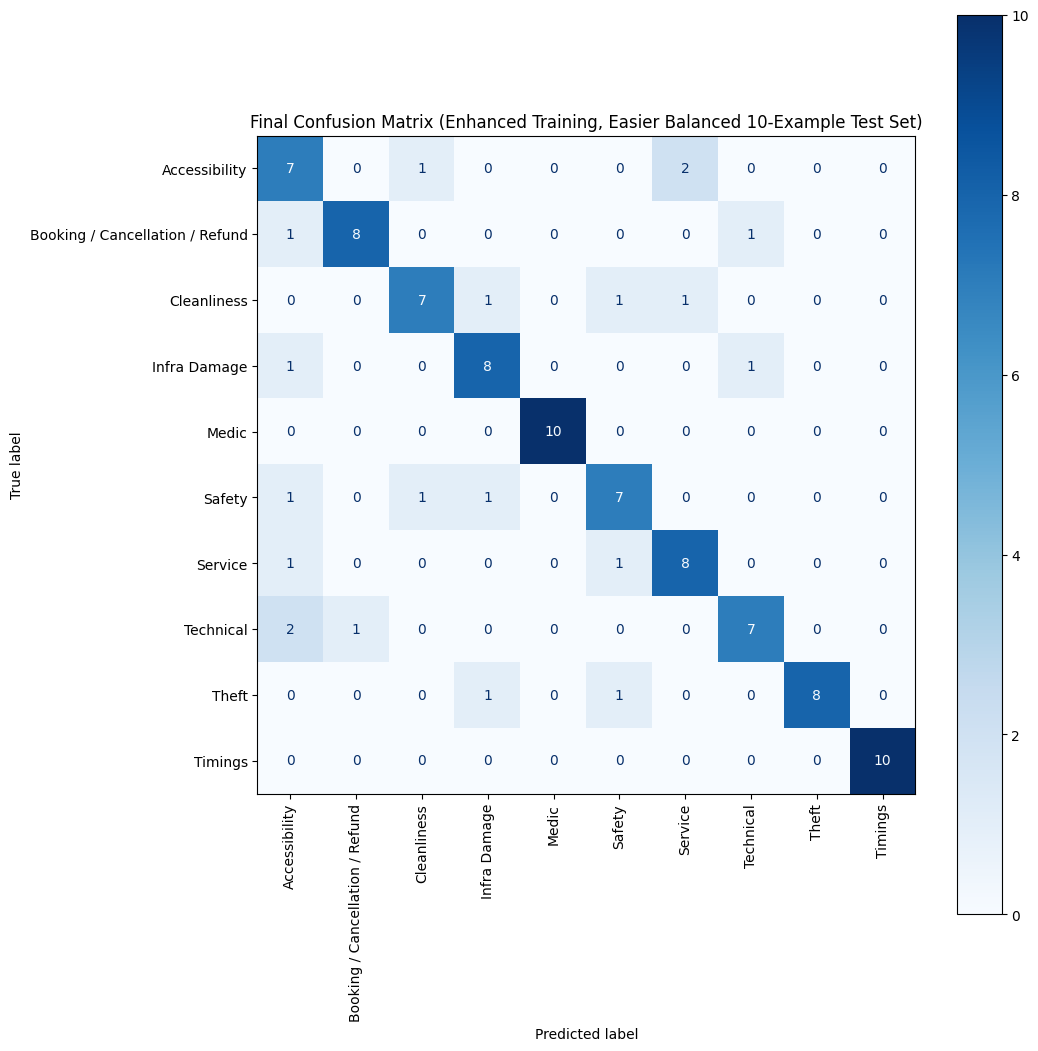


Final Classification Report:
                                 precision    recall  f1-score   support

                  Accessibility       0.54      0.70      0.61        10
Booking / Cancellation / Refund       0.89      0.80      0.84        10
                    Cleanliness       0.78      0.70      0.74        10
                   Infra Damage       0.73      0.80      0.76        10
                          Medic       1.00      1.00      1.00        10
                         Safety       0.70      0.70      0.70        10
                        Service       0.73      0.80      0.76        10
                      Technical       0.78      0.70      0.74        10
                          Theft       1.00      0.80      0.89        10
                        Timings       1.00      1.00      1.00        10

                       accuracy                           0.80       100
                      macro avg       0.81      0.80      0.80       100
                   

In [13]:
# --- Installations (uncomment and run if you haven't already) ---
# !pip install classy_classification scikit-learn matplotlib numpy spacy
# !python -m spacy download en_core_web_lg # Using a transformer model, but good practice

import spacy
import classy_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np
import operator # For sorting scores

# --- 1. Define FURTHER Expanded Training Data (with contrast examples) ---
print("Defining FURTHER expanded training data (with added contrast examples)...")
further_expanded_data = {
    "Safety": [
        "The train is not safe.", "The train is on fire.", "I smell a gas leak.",
        "There are some suspicious individuals that have boarded the train.",
        "Emergency alarm activated due to smoke.", "Observed someone tampering with the train door mechanism.",
        "Fighting broke out in the next carriage.", "Feels unsafe due to poor lighting and lack of security.",
        "Derailment reported on this line earlier.", "Concerns about track safety ahead.",
        "Report of person threatening staff.", "Suspicious package left unattended on seat.",
        # New contrast examples for Safety
        "Situation feels very unsafe due to aggressive drunk individuals.",
        "Emergency exit path is completely blocked by stored equipment.",
        "Urgent need for security personnel due to escalating argument.",
        "Platform overcrowding creating a dangerous crush risk near edge.",
        "That exposed electrical wire near the bench is a serious shock hazard."
        ],
    "Medic": [
        "My sister is having a heart attack.", "I am in need of urgent medical assistance.", "An old man is dying.",
        "Urgent medical assistance needed.", "Passenger fainted, requires immediate medical help.",
        "Someone is choking, please help!", "Severe allergic reaction happening now.",
        "Requesting first aid for an injury.", "Paramedics needed at the next station.",
        "Experiencing chest pains, need a doctor.", "Passenger fell down stairs, possibly injured.",
        "Child appears unwell, high fever."
        ],
    "Cleanliness": [
        "The seats are dirty.", "The station is full of trash.", "The pungent smell of the bathrooms are unbearable.",
        "Dirty", "Unclean", "Please clean up the spill in aisle 3.", "Toilets are blocked and overflowing.",
        "Graffiti on the walls.", "Food waste left on tables.", "Sticky floor near the entrance.",
        "Need sanitation crew attention.", "The bins haven't been emptied in days.", "Cobwebs in the corners."
        ],
    "Infra Damage": [
        "The platform is cracked and uneven, causing a tripping hazard.",
        "There are broken lights on the station platform making it unsafe to board the train at night.",
        "The staircase leading to the train is damaged and unstable.", "Building damage", "Train damage.",
        "Escalator is out of service again.", "Leaking roof in the waiting area.",
        "Broken window on the train carriage.", "Ticket barrier is malfunctioning / physically broken.",
        "Structural issues reported with the bridge.", "Damaged seating needs repair.",
        "Automatic doors are jammed.", "Signalling equipment failure reported.",
        # New contrast examples for Infra Damage
        "Section of ceiling plaster has fallen in main waiting room.",
        "One of the platform benches is severely damaged and unusable.",
        "Report of a persistently leaking pipe in the station underpass.",
        "The main departure information board has numerous dead pixels.",
        "Turnstile T3 has a broken barrier arm."
        ],
    "Technical": [
        "The website server has been down for the past 12 hours.", "Your server has crashed.", "The website is not running.",
        "Unable to log in to my account on the app.", "Payment gateway error during checkout.",
        "Wi-Fi connection is not working onboard.", "Digital display boards are showing incorrect information.",
        "App keeps crashing when I search for trains.", "Error message when trying to load e-ticket.",
        "The online timetable won't update.", "Ticket machine is frozen.", "Mobile app payment is failing."
        ],
    "Timings": [
        "The train was delayed by more than 3 hours without any prior notice.",
        "The departure time of the train was changed at the last minute, causing confusion.",
        "The train arrived at the station 30 minutes early, and we missed our connecting train.",
        "Constant delays on this route.", "Why is the train running so late?",
        "Schedule changes were not communicated properly.", "Missed connection due to late arrival.",
        "The estimated arrival time keeps changing.", "Train departed ahead of schedule.",
        "Frequency of trains reduced without warning.", "Board shows 'On Time' but train hasn't arrived.",
        "Cancellation of service with no alternative provided."
        ],
    "Booking / Cancellation / Refund": [
        "I was charged twice for my train ticket, but the refund process is taking too long.",
        "I tried to cancel my ticket online, but the system keeps showing an error.",
        "I did not receive a confirmation email for my booking, and I am unsure if my reservation is confirmed.",
        "I want to cancel my ticket.", "I want a refund.", "Need to amend my travel dates.",
        "Issue with seat reservation.", "How do I apply for a refund for a cancelled train?",
        "Booking failed but money was deducted.", "Difficulty purchasing tickets via the app/website.",
        "Where is my refund status?", "Need receipt for my past booking.", "Problem applying voucher code."
        ],
    "Accessibility": [
        "There are no ramps or elevators for wheelchair users at this station.",
        "The train does not have sufficient space or facilities for passengers with disabilities.",
        "There is no assistance available for elderly passengers or those with mobility issues at the station.",
        "Need help boarding with a wheelchair.", "Lack of audio announcements for visually impaired passengers.",
        "No accessible restrooms available.", "Requesting assistance for a passenger with reduced mobility.",
        "Gap between train and platform is too large.", "Signage is unclear for finding accessible routes.",
        "Priority seating is occupied and not enforced.", "Induction loop at ticket counter not working.",
        "Stairs are the only option to change platforms.",
         # New contrast examples for Accessibility
        "No Braille signage available anywhere in the station.",
        "The designated wheelchair space is too narrow for standard chairs.",
        "Requesting clarification on the policy for assistance animals.",
        "The hearing loop system at the counter seems faulty.",
        "Lack of step-free access between platforms 1 and 2."
       ],
    "Theft": [
        "My wallet was stolen from my bag while I was asleep on the train.",
        "There are reports of thefts happening frequently on this train route.",
        "I had some valuable items stolen from my luggage while it was stored in the overhead rack.",
        "I have been robbed.", "Someone pickpocketed me on the platform.", "My luggage was broken into.",
        "Reporting a stolen laptop.", "Suspicious activity, potential theft in progress.",
        "Warning about bag snatchers.", "Lost property likely due to theft.", "My bike was stolen from the rack.",
        "Someone attempted to steal my phone."
        ],
    "Service": [
        "The train staff are not responding to requests for help or assistance.",
        "The food served on the train is of poor quality and does not match the description.",
        "The cleaning staff are not attending to spills and messes in a timely manner.",
        "The service is bad.", "Rude conductor.", "Staff unable to provide information about delays.",
        "Air conditioning / heating is not working, staff unresponsive.",
        "Lack of onboard catering as advertised.", "Ticket inspector was unprofessional.",
        "No help available with luggage.", "Long queue at the ticket office, insufficient staff.",
        "Staff provided incorrect travel information.", "Lost property office is unhelpful.",
        # New contrast examples for Service
        "Staff member refused to help deploy the boarding ramp when asked.",
        "Received incorrect information about accessible toilet locations from staff.",
        "The information desk staff were unhelpful regarding platform changes.",
        "Despite requests, staff did not address the broken heating in carriage.",
        "Lost property office provided conflicting information."
        ]
}
print(f"Enhanced training data defined with {sum(len(v) for v in further_expanded_data.values())} examples.")
# Optional: Print new counts
# for category, examples in further_expanded_data.items():
#    print(f"Category '{category}': {len(examples)} training examples")

# --- 2. Train Model on ENHANCED Training Data ---
print("\nTraining model with ENHANCED (contrast added) training data...")
nlp_final = spacy.blank("en") # Use a new variable name for clarity
nlp_final.add_pipe(
    "classy_classification",
    config={
        "data": further_expanded_data, # Use the newest training data
        "model": "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
        "device": "cpu" # Change to "cuda" if GPU is available and configured
    }
)
print("Model re-training complete.")


# --- 3. Define the New BALANCED "Easier" Test Set (10 Examples per Category) ---
print("\nDefining the new BALANCED 'easier' test set (10 examples per category)...")
test_set_balanced_10_easier = [
    # Safety (Focus on Threat/Danger/Security)
    ("Man yelling threats at passengers, need security now.", "Safety"), ("Smoke detected in carriage 5, activating alarm.", "Safety"),
    ("Observed person attempting to force train door open.", "Safety"), ("Unattended backpack left near ticket barriers.", "Safety"),
    ("Fighting has broken out between two passengers.", "Safety"), ("Call security - suspicious individual filming passengers.", "Safety"),
    ("Person trespassing on the railway lines.", "Safety"), ("Report of chemical smell, potential gas leak.", "Safety"),
    ("Massive overcrowding, feels like a stampede risk.", "Safety"), ("Emergency phone on platform is broken/vandalized.", "Safety"),
    # Medic (Focus on Health Emergency)
    ("Passenger collapsed, unresponsive.", "Medic"), ("Woman having severe breathing difficulties.", "Medic"),
    ("Child bleeding heavily from a fall.", "Medic"), ("Passenger appears to be having a stroke.", "Medic"),
    ("Requesting urgent medical assistance at next stop.", "Medic"), ("Someone needs first aid for a deep cut.", "Medic"),
    ("Severe allergic reaction reported in carriage C.", "Medic"), ("Passenger complaining of sudden intense chest pain.", "Medic"),
    ("Need help for passenger who burned their hand badly.", "Medic"), ("Paramedics required for passenger with seizure.", "Medic"),
    # Cleanliness (Focus on Dirt/Mess/Hygiene)
    ("Spilled drink making the floor sticky and dirty.", "Cleanliness"), ("Toilets are disgusting, blocked and smell terrible.", "Cleanliness"),
    ("Seats have unknown stains and old food crumbs.", "Cleanliness"), ("Bins are completely full and trash is on the ground.", "Cleanliness"),
    ("Floor looks like it hasn't been mopped in weeks.", "Cleanliness"), ("Graffiti tags covering the train window.", "Cleanliness"),
    ("Someone was sick on the platform, needs cleaning.", "Cleanliness"), ("Waiting room tables covered in litter.", "Cleanliness"),
    ("Train windows are filthy, cannot see out.", "Cleanliness"), ("Please send cleaners, carriage 3 is very untidy.", "Cleanliness"),
    # Infra Damage (Focus on Broken Structure/Equipment)
    ("Ceiling panel loose and hanging down.", "Infra Damage"), ("Ticket gate barrier arm is snapped off.", "Infra Damage"),
    ("Deep crack running across the station platform.", "Infra Damage"), ("Seat is physically broken and cannot be used.", "Infra Damage"),
    ("Escalator is not working, showing error code.", "Infra Damage"), ("Platform edge is chipped and uneven.", "Infra Damage"),
    ("Water leaking significantly from pipe overhead.", "Infra Damage"), ("Stair handrail is loose and unstable.", "Infra Damage"),
    ("Light fixture cover is broken.", "Infra Damage"), ("Train window shattered.", "Infra Damage"),
    # Technical (Focus on System/Software/Connectivity Failure)
    ("Website shows 'Internal Server Error 500'.", "Technical"), ("Mobile app crashes immediately upon opening.", "Technical"),
    ("Cannot connect to 'TrainWiFi', network unavailable.", "Technical"), ("Ticket machine screen completely blank, won't turn on.", "Technical"),
    ("Online payment failing with 'transaction declined' error.", "Technical"), ("Departure board frozen, not updating times.", "Technical"),
    ("Error downloading ticket PDF from email link.", "Technical"), ("Website rejecting valid password for login.", "Technical"),
    ("Train tracker map on app is not loading data.", "Technical"), ("Password reset process is not sending the email.", "Technical"),
    # Timings (Focus on Schedule Deviations/Info)
    ("Train delayed over 2 hours now.", "Timings"), ("Last minute departure time change announced.", "Timings"),
    ("Train arrived 10 minutes ahead of schedule.", "Timings"), ("This route is frequently late.", "Timings"),
    ("Announcement says 'delayed', board says 'on time' - which is it?", "Timings"), ("Missed my flight because the train was late.", "Timings"),
    ("Why was the scheduled 8:15 train cancelled?", "Timings"), ("Train stopped between stations for 30 mins.", "Timings"),
    ("The online timetable differs from the station timetable.", "Timings"), ("Platform changed with very short notice.", "Timings"),
    # Booking / Cancellation / Refund (Focus on Transactions/Reservations)
    ("Need to change the date of my booked journey.", "Booking / Cancellation / Refund"), ("Error message when trying to cancel reservation online.", "Booking / Cancellation / Refund"),
    ("Query about refund status for ticket Ref ABC.", "Booking / Cancellation / Refund"), ("How do I reserve a seat using the app?", "Booking / Cancellation / Refund"),
    ("My card was charged twice for the same ticket.", "Booking / Cancellation / Refund"), ("Never received booking confirmation email.", "Booking / Cancellation / Refund"),
    ("Requesting refund for severely delayed service.", "Booking / Cancellation / Refund"), ("Can I add another passenger to my existing booking?", "Booking / Cancellation / Refund"),
    ("Voucher code not working during purchase.", "Booking / Cancellation / Refund"), ("Help required booking tickets for group travel.", "Booking / Cancellation / Refund"),
    # Accessibility (Focus on Lack of Access/Features/Aids)
    ("Boarding ramp is unavailable for wheelchair user.", "Accessibility"), ("No staff available to provide boarding assistance.", "Accessibility"),
    ("Audio announcements are completely inaudible.", "Accessibility"), ("This train carriage has no designated wheelchair space.", "Accessibility"),
    ("Where is the nearest accessible toilet?", "Accessibility"), ("No hearing loop available at the ticket office.", "Accessibility"),
    ("The lift providing step-free access is broken.", "Accessibility"), ("Signage for disabled access routes is missing.", "Accessibility"),
    ("Priority seats are occupied by non-priority passengers.", "Accessibility"), ("Information is not available in large print format.", "Accessibility"),
    # Theft (Focus on Stolen Items/Criminal Act)
    ("My wallet was stolen from my pocket.", "Theft"), ("Warning others about active pickpockets.", "Theft"),
    ("My locked bicycle was stolen from the station rack.", "Theft"), ("Someone took my laptop bag while I wasn't looking.", "Theft"),
    ("Reporting luggage stolen from the train.", "Theft"), ("Observed someone breaking into a car in the car park.", "Theft"),
    ("My phone was grabbed from my hand.", "Theft"), ("Ticket machine appears to have been forced open.", "Theft"),
    ("My passport is missing from my bag, likely stolen.", "Theft"), ("Backpack was opened and items taken.", "Theft"),
    # Service (Focus on Staff Actions/Attitude/Service Provision)
    ("Staff member at information desk was rude and unhelpful.", "Service"), ("Onboard heating is unbearable, staff won't adjust it.", "Service"),
    ("The advertised catering trolley did not appear.", "Service"), ("Cleaning staff ignored the mess when pointed out.", "Service"),
    ("Ticket inspector was unnecessarily confrontational.", "Service"), ("Cannot find any staff member to ask a question.", "Service"),
    ("Staff gave me completely wrong platform information.", "Service"), ("Lost property department was very difficult to deal with.", "Service"),
    ("Only one counter open, causing huge queues.", "Service"), ("Complaint about how staff handled a ticketing issue.", "Service"),
]

# Separate texts and true labels for the new "easier" balanced 10-example test set
test_texts_balanced_10_easier = [item[0] for item in test_set_balanced_10_easier]
true_labels_balanced_10_easier = [item[1] for item in test_set_balanced_10_easier]
num_categories = len(further_expanded_data)
examples_per_category = len(test_set_balanced_10_easier) // num_categories
print(f"New BALANCED 'easier' test set defined with {len(test_texts_balanced_10_easier)} examples ({examples_per_category} per category).")


# --- 4. Get Predictions on the "Easier" BALANCED 10-Example Test Set using the FINAL Model ---
print("\nGetting predictions on the 'easier' BALANCED 10-example test data using the FINAL model...")
predicted_labels = []
predicted_scores = [] # Store all scores for analysis
for text in test_texts_balanced_10_easier: # Use the easier balanced 10-example test texts
    doc = nlp_final(text) # Use the final re-trained model
    scores = doc._.cats
    predicted_scores.append(scores)
    if not scores:
         print(f"Warning: No categories predicted for test text: '{text}'")
         predicted_label = "None"
    else:
         # Get the category with the highest score
         predicted_label = max(scores, key=scores.get)
    predicted_labels.append(predicted_label)

# --- 5. Generate and Display the Confusion Matrix ---
print("\nGenerating Final Confusion Matrix (Enhanced Training, Easier Balanced 10-Example Test Set)...")

# Get all unique labels from the further expanded training data + any defaults like "None"
all_labels = sorted(list(further_expanded_data.keys()))
if "None" in predicted_labels and "None" not in all_labels:
    all_labels.append("None")

try:
    # Calculate the confusion matrix using easier balanced 10-example true labels
    cm = confusion_matrix(true_labels_balanced_10_easier, predicted_labels, labels=all_labels)

    # Display the matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=all_labels)
    fig, ax = plt.subplots(figsize=(11, 11)) # Slightly larger figure size
    disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
    plt.title("Final Confusion Matrix (Enhanced Training, Easier Balanced 10-Example Test Set)")
    plt.tight_layout()
    plt.show()

    # --- 6. Print Classification Report (Precision, Recall, F1-score) ---
    print("\nFinal Classification Report:")
    # Use easier balanced 10-example true labels and zero_division=0
    report = classification_report(true_labels_balanced_10_easier, predicted_labels, labels=all_labels, zero_division=0)
    print(report)

    # --- 7. Calculate and Print Top-2 Accuracy ---
    print("\nCalculating Final Top-N Accuracy...")
    top_n = 2
    correct_top_n = 0
    for i, scores in enumerate(predicted_scores):
        true_label = true_labels_balanced_10_easier[i] # Use easier balanced 10-example true labels
        if not scores: continue # Skip if no scores were predicted

        # Sort scores dictionary by value (score) in descending order
        sorted_scores = dict(sorted(scores.items(), key=operator.itemgetter(1), reverse=True))

        # Get the top N predicted labels
        top_n_preds = list(sorted_scores.keys())[:top_n]

        # Check if the true label is in the top N predictions
        if true_label in top_n_preds:
            correct_top_n += 1

    total_samples = len(true_labels_balanced_10_easier) # Use count from easier balanced 10-example set
    top_n_accuracy = (correct_top_n / total_samples) * 100 if total_samples > 0 else 0
    print(f"Final Top-{top_n} Accuracy: {top_n_accuracy:.2f}% ({correct_top_n}/{total_samples})")

    # --- 8. Analyze Scores for Misclassified Examples (Optional Detail) ---
    # (Code remains the same, just uses the balanced_10_easier variables now)
    # print("\nAnalysis of Misclassified Examples (Top Prediction vs True Label Score):")
    # for i, pred_label in enumerate(predicted_labels):
    #     true_label = true_labels_balanced_10_easier[i]
    #     if pred_label != true_label and predicted_scores[i]:
    #         pred_score = predicted_scores[i].get(pred_label, 0)
    #         true_label_score = predicted_scores[i].get(true_label, 0)
    #         print(f"Text: '{test_texts_balanced_10_easier[i]}'")
    #         print(f"  True: '{true_label}' (Score: {true_label_score:.3f}), Predicted: '{pred_label}' (Score: {pred_score:.3f})")


except Exception as e:
    print(f"\nError during evaluation: {e}")
    print("True Labels:", true_labels_balanced_10_easier)
    print("Predicted Labels:", predicted_labels)
    print("All Labels:", all_labels)